In [15]:
# Install RAPIDS (cuDF, cuML) for Colab
# This takes ~3-4 minutes. Use T4 GPU runtime.
!nvidia-smi
import subprocess, sys

# Install RAPIDS 24.x compatible with Colab CUDA
!pip install -q cudf-cu12 cuml-cu12 --extra-index-url=https://pypi.nvidia.com
!pip install -q xgboost ucimlrepo

Sun May  3 15:51:03 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   49C    P0             28W /   70W |     155MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [16]:
import numpy as np
import pandas as pd
import cupy as cp
import cudf
import time
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score
from sklearn.ensemble import RandomForestClassifier as skRF
from sklearn.datasets import load_breast_cancer

import cuml
from cuml.ensemble import RandomForestClassifier as cuRF
from cuml.linear_model import LogisticRegression as cuLR
import xgboost as xgb

print('cuDF version :', cudf.__version__)
print('cuML version :', cuml.__version__)
print('XGBoost version:', xgb.__version__)

cuDF version : 26.02.01
cuML version : 26.02.000
XGBoost version: 3.2.0


In [17]:
# ─────────────────────────────────────────────────────────────
# QUESTION 1 — Adult Census Income Dataset
# ─────────────────────────────────────────────────────────────

# Load Adult Income dataset
cols = ['age','workclass','fnlwgt','education','education_num',
        'marital_status','occupation','relationship','race','sex',
        'capital_gain','capital_loss','hours_per_week','native_country','income']

url = 'https://archive.ics.uci.edu/ml/machine-learning-databases/adult/adult.data'
df = pd.read_csv(url, names=cols, na_values=' ?', skipinitialspace=True)
df.dropna(inplace=True)
df.reset_index(drop=True, inplace=True)
print('Shape:', df.shape)
df.head()

Shape: (32561, 15)


,age,workclass,fnlwgt,education,education_num,marital_status,occupation,relationship,race,sex,capital_gain,capital_loss,hours_per_week,native_country,income
0,39,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,United-States,<=50K
1,50,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States,<=50K
2,38,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States,<=50K
3,53,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40,United-States,<=50K
4,28,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40,Cuba,<=50K


In [18]:
# Feature type classification
continuous  = ['age', 'fnlwgt', 'capital_gain', 'capital_loss', 'hours_per_week']
discrete    = ['education_num']
categorical = ['workclass', 'education', 'marital_status', 'occupation',
               'relationship', 'race', 'native_country']
binary      = ['sex', 'income']

print('Continuous  (histogram-eligible):', continuous)
print('Discrete    :', discrete)
print('Categorical :', categorical)
print('Binary      :', binary)

Continuous  (histogram-eligible): ['age', 'fnlwgt', 'capital_gain', 'capital_loss', 'hours_per_week']
Discrete    : ['education_num']
Categorical : ['workclass', 'education', 'marital_status', 'occupation', 'relationship', 'race', 'native_country']
Binary      : ['sex', 'income']


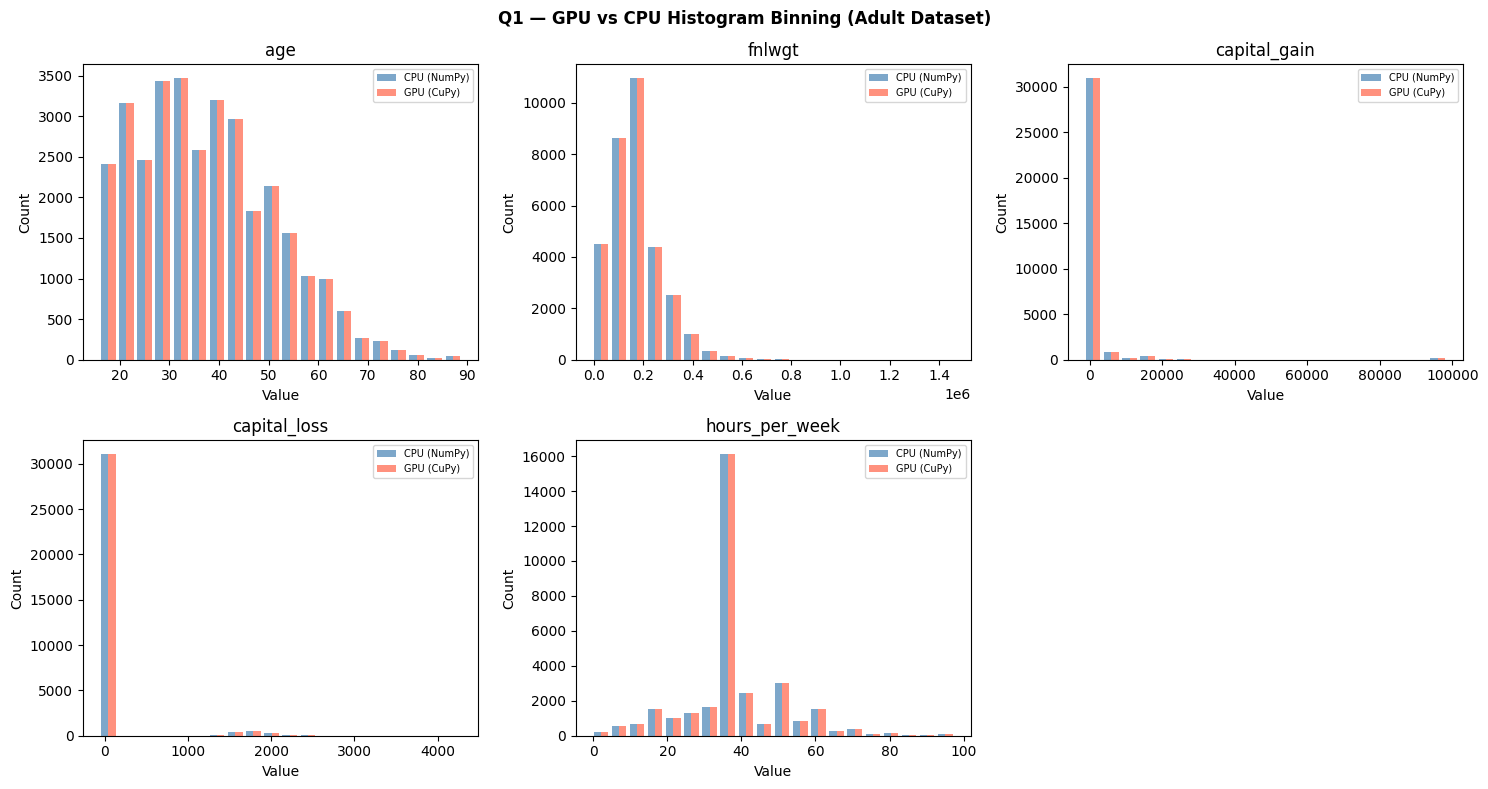

CPU histogram times (ms): ['0.800', '0.744', '0.759', '0.980', '0.810']
GPU histogram times (ms): ['2.161', '1.902', '1.774', '1.955', '1.849']


In [19]:
# GPU-based histogram binning with CuPy vs NumPy
BINS = 20
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()
features_to_plot = continuous[:5]

cpu_hist_times = []
gpu_hist_times = []

for i, feat in enumerate(features_to_plot):
    data_np = df[feat].values.astype(np.float32)
    data_cp = cp.array(data_np)

    # CPU histogram
    t0 = time.perf_counter()
    cpu_hist, cpu_edges = np.histogram(data_np, bins=BINS)
    cpu_hist_times.append(time.perf_counter() - t0)

    # GPU histogram
    t0 = time.perf_counter()
    gpu_hist, gpu_edges = cp.histogram(data_cp, bins=BINS)
    cp.cuda.Stream.null.synchronize()
    gpu_hist_times.append(time.perf_counter() - t0)

    ax = axes[i]
    width = (cpu_edges[1] - cpu_edges[0]) * 0.4
    ax.bar(cpu_edges[:-1],          cpu_hist,              width=width, label='CPU (NumPy)',  alpha=0.7, color='steelblue')
    ax.bar(cp.asnumpy(gpu_edges[:-1]) + width, cp.asnumpy(gpu_hist), width=width, label='GPU (CuPy)',   alpha=0.7, color='tomato')
    ax.set_title(f'{feat}')
    ax.set_xlabel('Value')
    ax.set_ylabel('Count')
    ax.legend(fontsize=7)

axes[-1].axis('off')
plt.suptitle('Q1 — GPU vs CPU Histogram Binning (Adult Dataset)', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('q1_histograms.png', dpi=120, bbox_inches='tight')
plt.show()

print('CPU histogram times (ms):', [f'{t*1000:.3f}' for t in cpu_hist_times])
print('GPU histogram times (ms):', [f'{t*1000:.3f}' for t in gpu_hist_times])

In [20]:
# Quantile binning — compute quantiles on GPU via cuDF, bin on CPU via pd.cut
# cudf.cut has a ColumnBase bug in newer RAPIDS; pd.cut is the safe workaround
N_QUANTILE_BINS = 5
gdf = cudf.from_pandas(df[continuous])

print('Quantile bin edges for each continuous feature:')
binned_df = pd.DataFrame()
for feat in continuous:
    # Quantile computation happens on GPU
    quantiles = gdf[feat].quantile([i/N_QUANTILE_BINS for i in range(N_QUANTILE_BINS+1)])
    edges = np.unique(quantiles.to_pandas().values)   # deduplicate for skewed features
    print(f'  {feat}: {np.round(edges, 2)}')
    # pd.cut with the GPU-computed edges
    binned_df[feat + '_bin'] = pd.cut(
        df[feat], bins=edges, labels=False, duplicates='drop', include_lowest=True
    )

# Convert result back to cuDF for downstream GPU use
binned_gdf = cudf.from_pandas(binned_df)
print('\nSample binned output:')
print(binned_gdf.head(10).to_pandas())

Quantile bin edges for each continuous feature:
  age: [17. 26. 33. 41. 50. 90.]
  fnlwgt: [  12285.  106648.  158662.  196338.  259873. 1484705.]
  capital_gain: [    0. 99999.]
  capital_loss: [   0. 4356.]
  hours_per_week: [ 1. 35. 40. 48. 99.]

Sample binned output:
   age_bin  fnlwgt_bin  capital_gain_bin  capital_loss_bin  hours_per_week_bin
0        2           0                 0                 0                   1
1        3           0                 0                 0                   0
2        2           3                 0                 0                   1
3        4           3                 0                 0                   1
4        1           4                 0                 0                   1
5        2           4                 0                 0                   1
6        3           2                 0                 0                   0
7        4           3                 0                 0                   2
8        1       

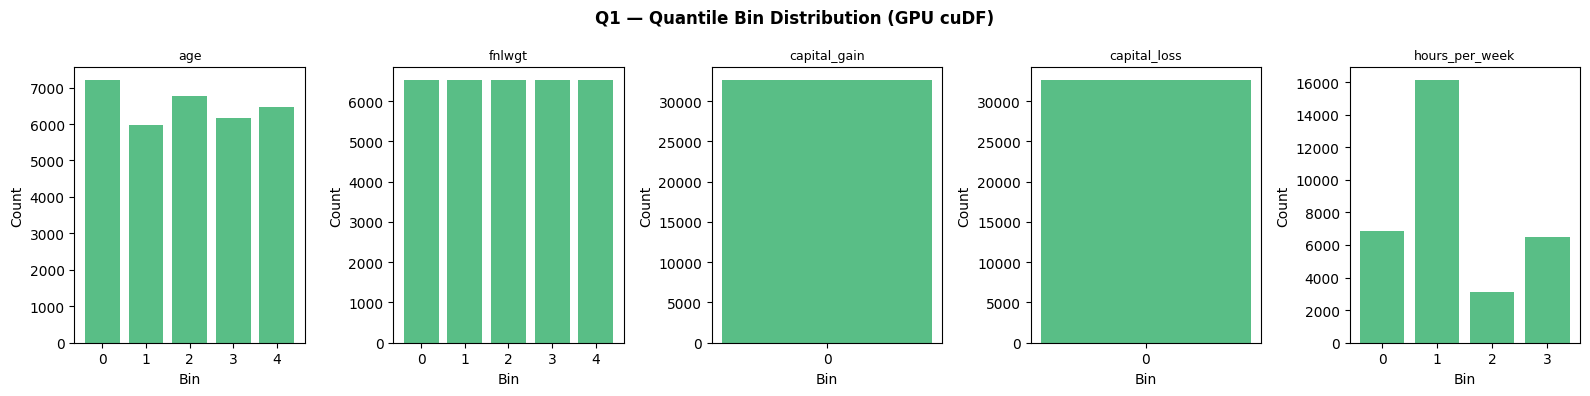

In [21]:
# Visualize balanced bin distribution from quantile binning
fig, axes = plt.subplots(1, len(continuous), figsize=(16, 4))
for ax, feat in zip(axes, continuous):
    counts = binned_gdf[feat + '_bin'].value_counts().to_pandas().sort_index()
    ax.bar(counts.index.astype(str), counts.values, color='mediumseagreen', alpha=0.85)
    ax.set_title(feat, fontsize=9)
    ax.set_xlabel('Bin')
    ax.set_ylabel('Count')
plt.suptitle('Q1 — Quantile Bin Distribution (GPU cuDF)', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('q1_quantile_bins.png', dpi=120, bbox_inches='tight')
plt.show()

In [22]:
# Preprocess for model training
df_enc = df.copy()
le = LabelEncoder()
for col in categorical + binary:
    df_enc[col] = le.fit_transform(df_enc[col].astype(str))

X = df_enc.drop('income', axis=1).astype(np.float32).values
y = df_enc['income'].astype(np.int32).values

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print('Train size:', X_train.shape, '| Test size:', X_test.shape)

Train size: (26048, 14) | Test size: (6513, 14)


In [23]:
# CPU model — scikit-learn Random Forest
t0 = time.perf_counter()
cpu_rf = skRF(n_estimators=100, random_state=42, n_jobs=-1)
cpu_rf.fit(X_train, y_train)
cpu_train_time = time.perf_counter() - t0

t0 = time.perf_counter()
cpu_preds = cpu_rf.predict(X_test)
cpu_pred_time = time.perf_counter() - t0
cpu_acc = accuracy_score(y_test, cpu_preds)

print(f'CPU RF — Train: {cpu_train_time:.3f}s | Predict: {cpu_pred_time:.4f}s | Accuracy: {cpu_acc:.4f}')

CPU RF — Train: 2.288s | Predict: 0.0985s | Accuracy: 0.8617


In [24]:
# GPU model — cuML Random Forest
X_train_cu = cudf.DataFrame(X_train)
X_test_cu  = cudf.DataFrame(X_test)
y_train_cu = cudf.Series(y_train.astype(np.int32))

t0 = time.perf_counter()
gpu_rf = cuRF(n_estimators=100, random_state=42, n_streams=1)
gpu_rf.fit(X_train_cu, y_train_cu)
gpu_train_time = time.perf_counter() - t0

t0 = time.perf_counter()
gpu_preds = gpu_rf.predict(X_test_cu).to_numpy()
gpu_pred_time = time.perf_counter() - t0
gpu_acc = accuracy_score(y_test, gpu_preds)

print(f'GPU RF — Train: {gpu_train_time:.3f}s | Predict: {gpu_pred_time:.4f}s | Accuracy: {gpu_acc:.4f}')
print(f'Speedup (train): {cpu_train_time/gpu_train_time:.2f}×')

GPU RF — Train: 0.535s | Predict: 0.0782s | Accuracy: 0.8630
Speedup (train): 4.28×


In [25]:
# XGBoost with gpu_hist
dtrain = xgb.DMatrix(X_train, label=y_train)
dtest  = xgb.DMatrix(X_test,  label=y_test)

# CPU XGBoost
params_cpu = {'tree_method': 'hist', 'eval_metric': 'error', 'verbosity': 0, 'nthread': -1}
t0 = time.perf_counter()
bst_cpu = xgb.train(params_cpu, dtrain, num_boost_round=100, verbose_eval=False)
xgb_cpu_train = time.perf_counter() - t0
xgb_cpu_preds = (bst_cpu.predict(dtest) > 0.5).astype(int)
xgb_cpu_acc   = accuracy_score(y_test, xgb_cpu_preds)

# GPU XGBoost
params_gpu = {'tree_method': 'hist', 'eval_metric': 'error', 'verbosity': 0, 'device': 'cuda'}
t0 = time.perf_counter()
bst_gpu = xgb.train(params_gpu, dtrain, num_boost_round=100, verbose_eval=False)
xgb_gpu_train = time.perf_counter() - t0
xgb_gpu_preds = (bst_gpu.predict(dtest) > 0.5).astype(int)
xgb_gpu_acc   = accuracy_score(y_test, xgb_gpu_preds)

print(f'XGBoost CPU — Train: {xgb_cpu_train:.3f}s | Acc: {xgb_cpu_acc:.4f}')
print(f'XGBoost GPU — Train: {xgb_gpu_train:.3f}s | Acc: {xgb_gpu_acc:.4f}')
print(f'XGBoost Speedup: {xgb_cpu_train/xgb_gpu_train:.2f}×')

XGBoost CPU — Train: 0.229s | Acc: 0.8733
XGBoost GPU — Train: 0.152s | Acc: 0.8735
XGBoost Speedup: 1.51×


In [26]:
# Q1 Results Table
q1_results = pd.DataFrame({
    'Model': ['sklearn RF (CPU)', 'cuML RF (GPU)', 'XGBoost CPU (hist)', 'XGBoost GPU (hist)'],
    'Train Time (s)': [round(cpu_train_time, 4), round(gpu_train_time, 4),
                       round(xgb_cpu_train, 4), round(xgb_gpu_train, 4)],
    'Accuracy': [round(cpu_acc, 4), round(gpu_acc, 4),
                 round(xgb_cpu_acc, 4), round(xgb_gpu_acc, 4)],
})
q1_results['Speedup vs CPU'] = [
    '1.00×',
    f'{cpu_train_time/gpu_train_time:.2f}×',
    '1.00×',
    f'{xgb_cpu_train/xgb_gpu_train:.2f}×',
]
print('\n=== Q1 — Model Comparison Table ===')
print(q1_results.to_string(index=False))


=== Q1 — Model Comparison Table ===
             Model  Train Time (s)  Accuracy Speedup vs CPU
  sklearn RF (CPU)          2.2885    0.8617          1.00×
     cuML RF (GPU)          0.5349    0.8630          4.28×
XGBoost CPU (hist)          0.2289    0.8733          1.00×
XGBoost GPU (hist)          0.1516    0.8735          1.51×


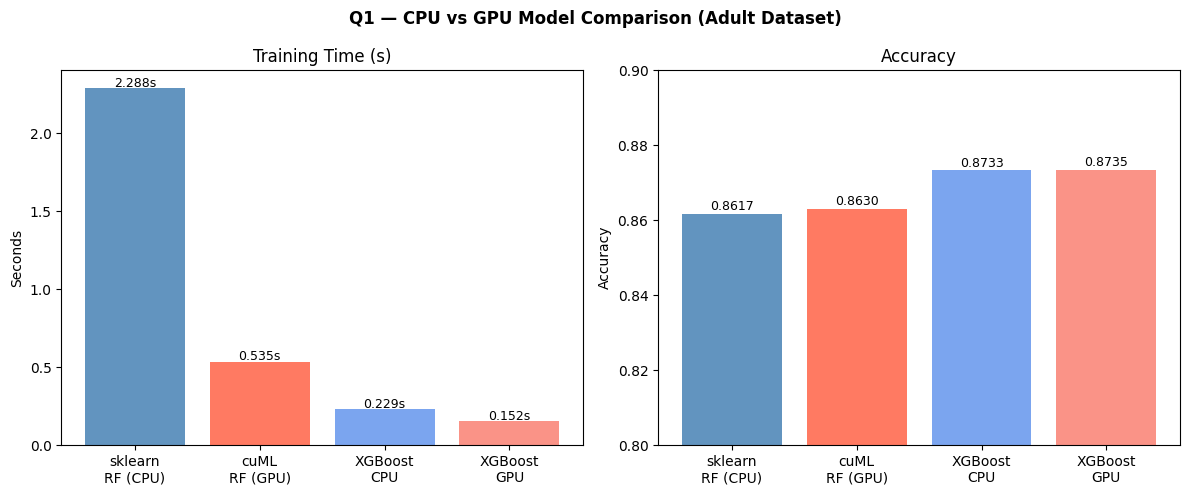

In [27]:
# Q1 Bar chart comparison
labels = ['sklearn\nRF (CPU)', 'cuML\nRF (GPU)', 'XGBoost\nCPU', 'XGBoost\nGPU']
times  = [cpu_train_time, gpu_train_time, xgb_cpu_train, xgb_gpu_train]
accs   = [cpu_acc, gpu_acc, xgb_cpu_acc, xgb_gpu_acc]
colors = ['steelblue', 'tomato', 'cornflowerblue', 'salmon']

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].bar(labels, times, color=colors, alpha=0.85)
axes[0].set_title('Training Time (s)')
axes[0].set_ylabel('Seconds')
for i, v in enumerate(times):
    axes[0].text(i, v + 0.01, f'{v:.3f}s', ha='center', fontsize=9)

axes[1].bar(labels, accs, color=colors, alpha=0.85)
axes[1].set_title('Accuracy')
axes[1].set_ylabel('Accuracy')
axes[1].set_ylim(0.8, 0.9)
for i, v in enumerate(accs):
    axes[1].text(i, v + 0.001, f'{v:.4f}', ha='center', fontsize=9)

plt.suptitle('Q1 — CPU vs GPU Model Comparison (Adult Dataset)', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('q1_model_comparison.png', dpi=120, bbox_inches='tight')
plt.show()

In [28]:
# ─────────────────────────────────────────────────────────────
# QUESTION 2 — Breast Cancer Dataset: sklearn vs cuML RF
# ─────────────────────────────────────────────────────────────

# Load and split dataset
bc = load_breast_cancer()
X_bc = bc.data.astype(np.float32)
y_bc = bc.target.astype(np.int32)

X_tr, X_te, y_tr, y_te = train_test_split(X_bc, y_bc, test_size=0.2, random_state=42)

# Convert to cuDF
X_tr_cu = cudf.DataFrame(X_tr)
X_te_cu = cudf.DataFrame(X_te)
y_tr_cu = cudf.Series(y_tr)

print('Dataset shape:', X_bc.shape)
print('Train size:', X_tr.shape, '| Test size:', X_te.shape)
print('Feature names:', list(bc.feature_names))

Dataset shape: (569, 30)
Train size: (455, 30) | Test size: (114, 30)
Feature names: [np.str_('mean radius'), np.str_('mean texture'), np.str_('mean perimeter'), np.str_('mean area'), np.str_('mean smoothness'), np.str_('mean compactness'), np.str_('mean concavity'), np.str_('mean concave points'), np.str_('mean symmetry'), np.str_('mean fractal dimension'), np.str_('radius error'), np.str_('texture error'), np.str_('perimeter error'), np.str_('area error'), np.str_('smoothness error'), np.str_('compactness error'), np.str_('concavity error'), np.str_('concave points error'), np.str_('symmetry error'), np.str_('fractal dimension error'), np.str_('worst radius'), np.str_('worst texture'), np.str_('worst perimeter'), np.str_('worst area'), np.str_('worst smoothness'), np.str_('worst compactness'), np.str_('worst concavity'), np.str_('worst concave points'), np.str_('worst symmetry'), np.str_('worst fractal dimension')]


In [29]:
# CPU — scikit-learn Random Forest
t0 = time.perf_counter()
sk_rf = skRF(n_estimators=100, random_state=42, n_jobs=-1)
sk_rf.fit(X_tr, y_tr)
sk_train_t = time.perf_counter() - t0

t0 = time.perf_counter()
sk_preds = sk_rf.predict(X_te)
sk_pred_t = time.perf_counter() - t0
sk_acc = accuracy_score(y_te, sk_preds)

print(f'sklearn RF — Train: {sk_train_t:.4f}s | Predict: {sk_pred_t:.4f}s | Acc: {sk_acc:.4f}')

sklearn RF — Train: 0.2553s | Predict: 0.0331s | Acc: 0.9649


In [30]:
# GPU — cuML Random Forest
t0 = time.perf_counter()
cu_rf = cuRF(n_estimators=100, random_state=42, n_streams=1)
cu_rf.fit(X_tr_cu, y_tr_cu)
cu_train_t = time.perf_counter() - t0

t0 = time.perf_counter()
cu_preds = cu_rf.predict(X_te_cu).to_numpy()
cu_pred_t = time.perf_counter() - t0
cu_acc = accuracy_score(y_te, cu_preds)

gpu_speedup = sk_train_t / cu_train_t
print(f'cuML RF   — Train: {cu_train_t:.4f}s | Predict: {cu_pred_t:.4f}s | Acc: {cu_acc:.4f}')
print(f'GPU Speedup: {gpu_speedup:.2f}×')

cuML RF   — Train: 0.1629s | Predict: 0.0041s | Acc: 0.9649
GPU Speedup: 1.57×


In [31]:
# Forest-Level Parallelism: Training time vs number of trees
n_estimators_list = [1, 10, 50, 100]
sk_times_forest, cu_times_forest = [], []

for n in n_estimators_list:
    t0 = time.perf_counter()
    skRF(n_estimators=n, random_state=42, n_jobs=-1).fit(X_tr, y_tr)
    sk_times_forest.append(time.perf_counter() - t0)

    t0 = time.perf_counter()
    cuRF(n_estimators=n, random_state=42, n_streams=1).fit(X_tr_cu, y_tr_cu)
    cu_times_forest.append(time.perf_counter() - t0)

print('n_estimators:', n_estimators_list)
print('CPU times (s):', [round(t, 4) for t in sk_times_forest])
print('GPU times (s):', [round(t, 4) for t in cu_times_forest])

n_estimators: [1, 10, 50, 100]
CPU times (s): [0.017, 0.0388, 0.1517, 0.2526]
GPU times (s): [0.007, 0.0207, 0.082, 0.1701]


In [32]:
# Feature-Level Parallelism: Feature importance
feat_imp = sk_rf.feature_importances_
feat_names = bc.feature_names
top_idx = np.argsort(feat_imp)[::-1][:10]

print('Top 10 feature importances (sklearn RF):')
for i in top_idx:
    print(f'  {feat_names[i]}: {feat_imp[i]:.4f}')

Top 10 feature importances (sklearn RF):
  worst area: 0.1539
  worst concave points: 0.1447
  mean concave points: 0.1062
  worst radius: 0.0780
  mean concavity: 0.0680
  worst perimeter: 0.0671
  mean perimeter: 0.0533
  mean radius: 0.0487
  mean area: 0.0476
  worst concavity: 0.0318


In [33]:
# Data-Level Parallelism: Training time vs dataset size
sizes = [50, 100, 200, 300, 400, len(X_tr)]
sk_times_data, cu_times_data = [], []

for s in sizes:
    Xs = X_tr[:s]; ys = y_tr[:s]
    Xs_cu = cudf.DataFrame(Xs)
    ys_cu = cudf.Series(ys)

    t0 = time.perf_counter()
    skRF(n_estimators=50, random_state=42, n_jobs=-1).fit(Xs, ys)
    sk_times_data.append(time.perf_counter() - t0)

    t0 = time.perf_counter()
    cuRF(n_estimators=50, random_state=42, n_streams=1).fit(Xs_cu, ys_cu)
    cu_times_data.append(time.perf_counter() - t0)

print('Dataset sizes:', sizes)
print('CPU times (s):', [round(t, 4) for t in sk_times_data])
print('GPU times (s):', [round(t, 4) for t in cu_times_data])

Dataset sizes: [50, 100, 200, 300, 400, 455]
CPU times (s): [0.1321, 0.1455, 0.1325, 0.1169, 0.1201, 0.129]
GPU times (s): [0.0489, 0.0723, 0.078, 0.0789, 0.0808, 0.0832]


In [34]:
# Bin-Level Parallelism: GPU histogram binning with CuPy
X_bc_cp = cp.array(X_bc)
BINS = 10

gpu_bin_times, cpu_bin_times = [], []
for i in range(X_bc.shape[1]):
    t0 = time.perf_counter()
    h, e = cp.histogram(X_bc_cp[:, i], bins=BINS)
    cp.cuda.Stream.null.synchronize()
    gpu_bin_times.append(time.perf_counter() - t0)

    t0 = time.perf_counter()
    h2, e2 = np.histogram(X_bc[:, i], bins=BINS)
    cpu_bin_times.append(time.perf_counter() - t0)

print(f'GPU bin avg time: {np.mean(gpu_bin_times)*1000:.3f} ms')
print(f'CPU bin avg time: {np.mean(cpu_bin_times)*1000:.3f} ms')
print(f'Bin Speedup: {np.mean(cpu_bin_times)/np.mean(gpu_bin_times):.2f}×')

GPU bin avg time: 7.029 ms
CPU bin avg time: 0.169 ms
Bin Speedup: 0.02×


In [35]:
# Q2 Performance Comparison Table
q2_table = pd.DataFrame({
    'Metric': ['Train Time (s)', 'Predict Time (s)', 'Accuracy', 'GPU Speedup'],
    'sklearn (CPU)': [round(sk_train_t, 4), round(sk_pred_t, 4), round(sk_acc, 4), '1.00×'],
    'cuML (GPU)':    [round(cu_train_t, 4), round(cu_pred_t, 4), round(cu_acc, 4), f'{gpu_speedup:.2f}×'],
})
print('\n=== Q2 — Performance Comparison Table ===')
print(q2_table.to_string(index=False))


=== Q2 — Performance Comparison Table ===
          Metric sklearn (CPU) cuML (GPU)
  Train Time (s)        0.2553     0.1629
Predict Time (s)        0.0331     0.0041
        Accuracy        0.9649     0.9649
     GPU Speedup         1.00×      1.57×


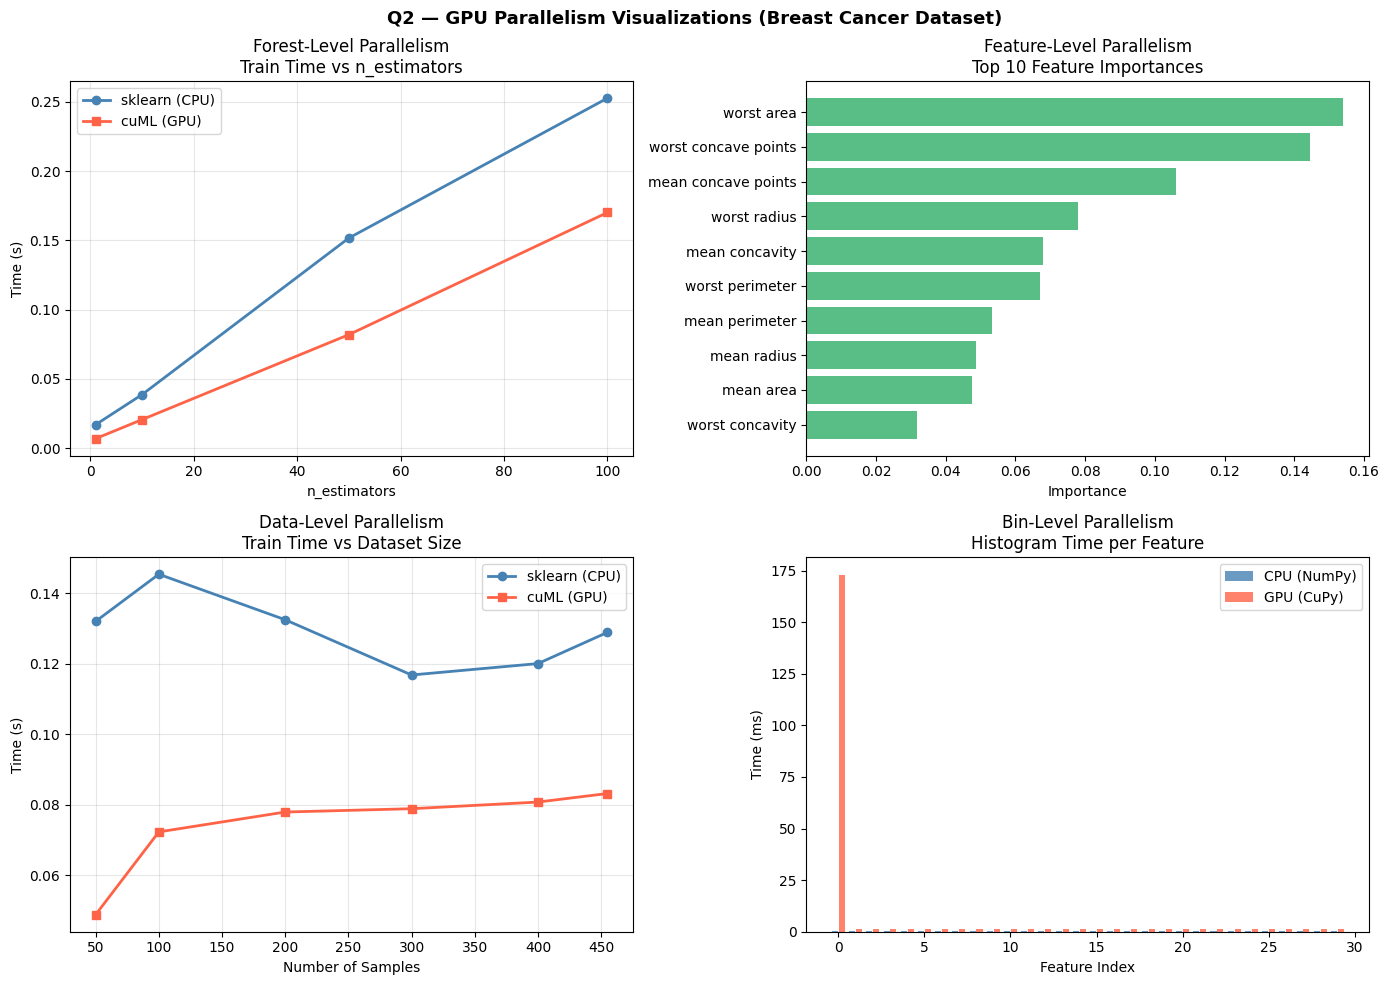

In [36]:
# Q2 — All 4 visualizations
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Q2 — GPU Parallelism Visualizations (Breast Cancer Dataset)', fontsize=13, fontweight='bold')

# 1. Forest-Level: training time vs n_estimators
ax = axes[0][0]
ax.plot(n_estimators_list, sk_times_forest, 'o-', color='steelblue', label='sklearn (CPU)', linewidth=2)
ax.plot(n_estimators_list, cu_times_forest, 's-', color='tomato',    label='cuML (GPU)',   linewidth=2)
ax.set_title('Forest-Level Parallelism\nTrain Time vs n_estimators')
ax.set_xlabel('n_estimators')
ax.set_ylabel('Time (s)')
ax.legend()
ax.grid(True, alpha=0.3)

# 2. Feature-Level: feature importances (top 10)
ax = axes[0][1]
ax.barh(feat_names[top_idx][::-1], feat_imp[top_idx][::-1], color='mediumseagreen', alpha=0.85)
ax.set_title('Feature-Level Parallelism\nTop 10 Feature Importances')
ax.set_xlabel('Importance')

# 3. Data-Level: training time vs dataset size
ax = axes[1][0]
ax.plot(sizes, sk_times_data, 'o-', color='steelblue', label='sklearn (CPU)', linewidth=2)
ax.plot(sizes, cu_times_data, 's-', color='tomato',    label='cuML (GPU)',   linewidth=2)
ax.set_title('Data-Level Parallelism\nTrain Time vs Dataset Size')
ax.set_xlabel('Number of Samples')
ax.set_ylabel('Time (s)')
ax.legend()
ax.grid(True, alpha=0.3)

# 4. Bin-Level: GPU vs CPU histogram time per feature
ax = axes[1][1]
feat_idx = np.arange(len(gpu_bin_times))
ax.bar(feat_idx - 0.2, [t*1000 for t in cpu_bin_times], 0.35, label='CPU (NumPy)', color='steelblue', alpha=0.8)
ax.bar(feat_idx + 0.2, [t*1000 for t in gpu_bin_times], 0.35, label='GPU (CuPy)',  color='tomato',    alpha=0.8)
ax.set_title('Bin-Level Parallelism\nHistogram Time per Feature')
ax.set_xlabel('Feature Index')
ax.set_ylabel('Time (ms)')
ax.legend()

plt.tight_layout()
plt.savefig('q2_parallelism.png', dpi=120, bbox_inches='tight')
plt.show()

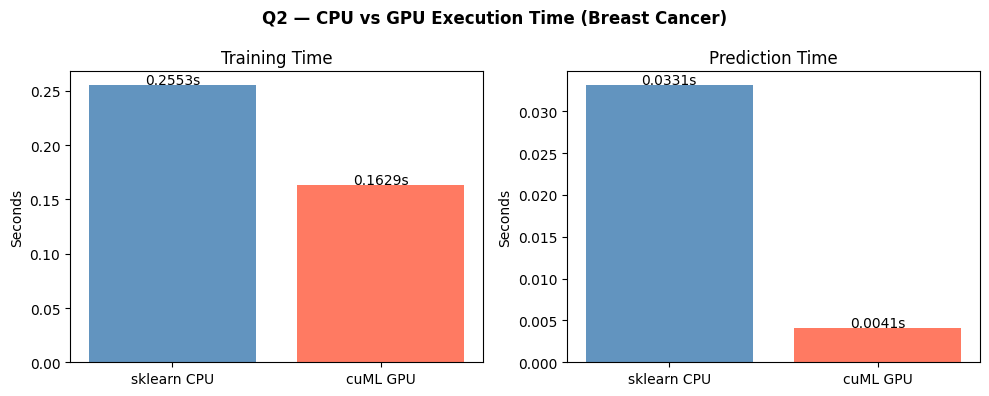

In [37]:
# Q2 — Execution time bar chart (CPU vs GPU)
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

axes[0].bar(['sklearn CPU', 'cuML GPU'], [sk_train_t, cu_train_t],
            color=['steelblue', 'tomato'], alpha=0.85)
axes[0].set_title('Training Time')
axes[0].set_ylabel('Seconds')
for i, v in enumerate([sk_train_t, cu_train_t]):
    axes[0].text(i, v + 0.001, f'{v:.4f}s', ha='center', fontsize=10)

axes[1].bar(['sklearn CPU', 'cuML GPU'], [sk_pred_t, cu_pred_t],
            color=['steelblue', 'tomato'], alpha=0.85)
axes[1].set_title('Prediction Time')
axes[1].set_ylabel('Seconds')
for i, v in enumerate([sk_pred_t, cu_pred_t]):
    axes[1].text(i, v + 0.0001, f'{v:.4f}s', ha='center', fontsize=10)

plt.suptitle('Q2 — CPU vs GPU Execution Time (Breast Cancer)', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('q2_timing_bars.png', dpi=120, bbox_inches='tight')
plt.show()

In [38]:
# Final Summary
print('=' * 55)
print('        UCS547 Assignment VI — Summary')
print('=' * 55)
print('\n[ Q1 — Adult Census Dataset ]')
print(f'  cuML RF speedup over sklearn RF : {cpu_train_time/gpu_train_time:.2f}×')
print(f'  XGBoost GPU speedup over CPU    : {xgb_cpu_train/xgb_gpu_train:.2f}×')
print(f'  cuML RF accuracy                : {gpu_acc:.4f}')
print(f'  XGBoost GPU accuracy            : {xgb_gpu_acc:.4f}')
print('\n[ Q2 — Breast Cancer Dataset ]')
print(f'  sklearn RF accuracy             : {sk_acc:.4f}')
print(f'  cuML RF accuracy                : {cu_acc:.4f}')
print(f'  GPU training speedup            : {gpu_speedup:.2f}×')
print(f'  Bin-level GPU speedup (avg)     : {np.mean(cpu_bin_times)/np.mean(gpu_bin_times):.2f}×')
print('=' * 55)

        UCS547 Assignment VI — Summary

[ Q1 — Adult Census Dataset ]
  cuML RF speedup over sklearn RF : 4.28×
  XGBoost GPU speedup over CPU    : 1.51×
  cuML RF accuracy                : 0.8630
  XGBoost GPU accuracy            : 0.8735

[ Q2 — Breast Cancer Dataset ]
  sklearn RF accuracy             : 0.9649
  cuML RF accuracy                : 0.9649
  GPU training speedup            : 1.57×
  Bin-level GPU speedup (avg)     : 0.02×
